# FIT5149 Assessment 1: Kaggle attempt 5

Group 43.

We train the same two-stage CatBoost model three times, with seeds 42, 73, and 2026. We average the three complete dollar predictions with equal weights. This reduces dependence on one random training run without choosing weights from the Kaggle leaderboard.

This candidate is kept separately. The root final notebook still reproduces attempt 4 until the team makes its final selection.

In [1]:
# Imports and reproducibility settings
from pathlib import Path
import os
import platform
import sys
import time

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import catboost

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier, CatBoostRegressor

RANDOM_STATE = 42
N_SPLITS = 5
TARGET = "sanctioned_amount_aud"

np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

def rmse(actual, predicted):
    return mean_squared_error(actual, predicted) ** 0.5


## 1. Load the supplied data

The three input CSVs are in the repository root, one folder above this notebook. It can also run from the root folder.

In [2]:
DATA_DIR = Path.cwd()

if not (DATA_DIR / "training_set.csv").exists():
    candidate = Path.cwd().parent
    if (candidate / "training_set.csv").exists():
        DATA_DIR = candidate

train = pd.read_csv(DATA_DIR / "training_set.csv")
test = pd.read_csv(DATA_DIR / "kaggle_test_X.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"Training data: {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"Kaggle test:   {test.shape[0]:,} rows x {test.shape[1]} columns")
print(f"Submission:    {sample_submission.shape[0]:,} rows x {sample_submission.shape[1]} columns")


Training data: 19,322 rows x 29 columns
Kaggle test:   10,000 rows x 28 columns
Submission:    10,000 rows x 2 columns


## 2. File and schema integrity checks

These checks fail early if the supplied competition files do not match the expected schema or row identifiers.


In [3]:
expected_train_shape = (19_322, 29)
expected_test_shape = (10_000, 28)

assert train.shape == expected_train_shape
assert test.shape == expected_test_shape
assert TARGET in train.columns and TARGET not in test.columns
assert train.drop(columns=TARGET).columns.tolist() == test.columns.tolist()
assert train["application_id"].is_unique
assert test["application_id"].is_unique
assert test["application_id"].equals(sample_submission["application_id"])
assert sample_submission.columns.tolist() == ["application_id", TARGET]
assert train["application_id"].str.fullmatch(r"LN-\d{6}").all()
assert test["application_id"].str.fullmatch(r"LN-\d{6}").all()

train_dates = pd.to_datetime(
    train["application_date"],
    format="%d/%m/%Y",
    errors="raise",
)
test_dates = pd.to_datetime(
    test["application_date"],
    format="%d/%m/%Y",
    errors="raise",
)

integrity_checks = pd.Series({
    "training_rows": len(train),
    "test_rows": len(test),
    "duplicate_training_rows": int(train.duplicated().sum()),
    "duplicate_test_rows": int(test.duplicated().sum()),
    "duplicate_training_ids": int(train["application_id"].duplicated().sum()),
    "duplicate_test_ids": int(test["application_id"].duplicated().sum()),
    "shared_ids_between_train_and_test": int(
        train["application_id"].isin(test["application_id"]).sum()
    ),
    "training_date_min": train_dates.min().date(),
    "training_date_max": train_dates.max().date(),
    "test_date_min": test_dates.min().date(),
    "test_date_max": test_dates.max().date(),
})

print("All schema and identifier checks passed.")
display(integrity_checks)


All schema and identifier checks passed.


training_rows                             19322
test_rows                                 10000
duplicate_training_rows                       0
duplicate_test_rows                           0
duplicate_training_ids                        0
duplicate_test_ids                            0
shared_ids_between_train_and_test             0
training_date_min                    2023-01-01
training_date_max                    2024-12-30
test_date_min                        2023-01-01
test_date_max                        2024-12-30
dtype: object

## 3. Target formulation

We first estimate the probability that an application receives a positive amount. A second model learns the sanction rate using approved applications only. The final amount is the probability of approval multiplied by the expected positive rate and the amount requested. We keep probabilities rather than using a hard approve/reject cutoff, because uncertain cases still contribute to squared error.

The observed tiers are used for stratification only. They are not model inputs.

In [4]:
y = train[TARGET].copy()
requested = train["requested_amount_aud"]
requested_array = requested.to_numpy()

assert (requested > 0).all()

sanction_rate = (y / requested).round(2).astype(float)

target_checks = pd.Series({
    "zero_target_n": int((y == 0).sum()),
    "zero_target_pct": 100 * (y == 0).mean(),
    "sanction_above_request_n": int((y > requested).sum()),
    "unique_rounded_sanction_rates": sorted(sanction_rate.unique().tolist()),
})

display(target_checks)


zero_target_n                                                           5177
zero_target_pct                                                       26.793
sanction_above_request_n                                                   0
unique_rounded_sanction_rates    [0.0, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 1.0]
dtype: object

## 4. Final cleaning and feature engineering

The same deterministic transformations are applied to the labelled and Kaggle-test data. Confirmed sentinel codes are converted to missing values, informative missingness indicators are retained, calendar and lending-related features are created, and fields excluded during development are removed before modelling.


In [5]:
SENTINEL_COLUMNS = [
    "existing_repayments_aud",
    "has_co_applicant",
    "property_value_aud",
]

MISSING_INDICATOR_COLUMNS = [
    column
    for column in train.drop(columns=TARGET).columns
    if train[column].isna().any() or column in SENTINEL_COLUMNS
]

def engineer_features(frame):
    x = frame.copy()

    # Convert confirmed encoded missing values.
    for column in SENTINEL_COLUMNS:
        x[column] = x[column].replace(-999, np.nan)

    # Preserve missingness information.
    x["missing_value_count"] = x.isna().sum(axis=1)

    for column in MISSING_INDICATOR_COLUMNS:
        x[f"{column}_is_missing"] = x[column].isna().astype("int8")

    # Calendar features.
    application_date = pd.to_datetime(
        x.pop("application_date"),
        format="%d/%m/%Y",
        errors="raise",
    )

    x["application_year"] = application_date.dt.year
    x["application_month_sin"] = np.sin(
        2 * np.pi * application_date.dt.month / 12
    )
    x["application_month_cos"] = np.cos(
        2 * np.pi * application_date.dt.month / 12
    )
    x["application_dayofyear_sin"] = np.sin(
        2 * np.pi * application_date.dt.dayofyear / 365.25
    )
    x["application_dayofyear_cos"] = np.cos(
        2 * np.pi * application_date.dt.dayofyear / 365.25
    )

    # Reconcile annual and monthly income.
    income_candidates = pd.concat(
        [
            x["annual_income_aud"],
            12 * x["monthly_income_aud"],
        ],
        axis=1,
    )

    x["annual_income_reconciled_aud"] = income_candidates.median(
        axis=1,
        skipna=True,
    )
    x["income_sources_available"] = income_candidates.notna().sum(axis=1)

    x["income_relative_gap"] = (
        (x["annual_income_aud"] - 12 * x["monthly_income_aud"]).abs()
        / x["annual_income_reconciled_aud"].replace(0, np.nan)
    )

    # Lending-related ratios.
    x["requested_to_property_value"] = (
        x["requested_amount_aud"]
        / x["property_value_aud"].replace(0, np.nan)
    )

    x["requested_to_annual_income"] = (
        x["requested_amount_aud"]
        / x["annual_income_reconciled_aud"].replace(0, np.nan)
    )

    x["repayments_to_monthly_income"] = (
        x["existing_repayments_aud"]
        / (x["annual_income_reconciled_aud"] / 12).replace(0, np.nan)
    )

    x["property_value_minus_requested"] = (
        x["property_value_aud"] - x["requested_amount_aud"]
    )

    # Remove the row identifier, corrupted field, and excluded property reference.
    x = x.drop(
        columns=[
            "application_id",
            "property_age_years",
            "property_ref",
        ]
    )

    return x

X_selected = engineer_features(train.drop(columns=TARGET))
X_kaggle_selected = engineer_features(test)

assert X_selected.columns.tolist() == X_kaggle_selected.columns.tolist()
assert not np.isinf(
    X_selected.select_dtypes(include="number").to_numpy()
).any()

selected_categorical_features = (
    X_selected
    .select_dtypes(include=["object", "string", "category"])
    .columns
    .tolist()
)

# CatBoost categorical values are converted to explicit strings.
for column in selected_categorical_features:
    X_selected[column] = (
        X_selected[column]
        .astype("string")
        .fillna("__MISSING__")
        .astype(str)
    )

    X_kaggle_selected[column] = (
        X_kaggle_selected[column]
        .astype("string")
        .fillna("__MISSING__")
        .astype(str)
    )

print(f"Final predictor count: {X_selected.shape[1]}")
print(f"Categorical predictors: {len(selected_categorical_features)}")


Final predictor count: 49
Categorical predictors: 12


## 5. Validation design

A fixed five-fold `StratifiedKFold` split is used for reproducible model validation. Stratification is based only on the observed sanction-rate tier so that each fold contains a similar target composition.


In [6]:
strata = sanction_rate.map(lambda value: f"{value:.2f}")

splitter = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

folds = list(
    splitter.split(
        X_selected,
        strata,
    )
)

fold_balance = []

for fold_number, (_, valid_index) in enumerate(folds, start=1):
    counts = (
        strata.iloc[valid_index]
        .value_counts(normalize=True)
        .sort_index()
    )
    fold_balance.append(
        counts.rename(f"fold_{fold_number}")
    )

display(
    pd.concat(fold_balance, axis=1)
    .T
    .style
    .format("{:.2%}")
)


,0.00,0.65,0.70,0.75,0.80,0.85,0.90,1.00
fold_1,26.78%,16.84%,29.44%,13.30%,12.94%,0.23%,0.26%,0.21%
fold_2,26.80%,16.87%,29.42%,13.27%,12.94%,0.23%,0.26%,0.21%
fold_3,26.81%,16.87%,29.43%,13.28%,12.94%,0.21%,0.26%,0.21%
fold_4,26.79%,16.85%,29.43%,13.30%,12.97%,0.21%,0.26%,0.21%
fold_5,26.79%,16.85%,29.43%,13.30%,12.97%,0.21%,0.26%,0.21%


## 6. Candidate for attempt 5

We train the same two-stage CatBoost model three times, with seeds 42, 73, and 2026. We average the three complete dollar predictions with equal weights. This reduces dependence on one random training run without choosing weights from the Kaggle leaderboard.

In [7]:
MODEL_NAME = 'seed_average'
CANDIDATE_CONFIG = {'seeds': [42, 73, 2026], 'approval_iterations': 1200, 'weight_power': 0}

def fit_candidate(features, amounts, categories, config):
    # All fitting and weighting use this training fold only.
    requested = features["requested_amount_aud"].to_numpy()
    rates = (np.asarray(amounts) / requested).round(2)
    approved = np.asarray(amounts) > 0
    members = []
    for seed in config["seeds"]:
        shared = dict(learning_rate=0.03, l2_leaf_reg=10.0, random_seed=seed,
                      thread_count=6, verbose=False, allow_writing_files=False)
        approval_options, rate_options = {}, {}
        if config["weight_power"]:
            weights = requested ** config["weight_power"]
            approval_options["sample_weight"] = weights / weights.mean()
            rate_options["sample_weight"] = weights[approved] / weights[approved].mean()
        if config.get("approval_objective") == "squared":
            approval = CatBoostRegressor(loss_function="RMSE", depth=config["approval_depth"],
                                        iterations=config["approval_iterations"], **shared)
        else:
            approval = CatBoostClassifier(loss_function="Logloss", depth=5,
                                         iterations=config["approval_iterations"], **shared)
        approval.fit(features, approved.astype(int), cat_features=categories, **approval_options)
        rate = CatBoostRegressor(loss_function="RMSE", depth=4, iterations=800, **shared)
        rate.fit(features.loc[approved], rates[approved], cat_features=categories, **rate_options)
        members.append((approval, rate))
    return members


def predict_candidate(members, features):
    # Average the complete dollar predictions, not the two stages separately.
    requested = features["requested_amount_aud"].to_numpy()
    predictions = []
    for approval, rate in members:
        if isinstance(approval, CatBoostClassifier):
            positive_column = list(approval.classes_).index(1)
            probability = approval.predict_proba(features)[:, positive_column]
        else:
            probability = np.clip(approval.predict(features), 0, 1)
        positive_rate = np.clip(rate.predict(features), 0, 1)
        predictions.append(requested * probability * positive_rate)
    return np.clip(np.mean(predictions, axis=0), 0, requested)


def fit_final_model(features, amounts):
    return fit_candidate(features, amounts, selected_categorical_features, CANDIDATE_CONFIG)

def predict_final_model(models, features):
    return predict_candidate(models, features)


## 7. Five-fold validation and feature checks

We score predictions in AUD. The mean fold RMSE matches the metric used in our earlier comparisons; the global OOF RMSE is calculated across all validation predictions together. These two summaries need not be identical.

We also shuffle five inputs identified in the earlier analysis, using three repeats per fold. This checks whether the selected model depends on those inputs. It is not a ranking of every feature, a causal test, or a significance test. Correlated inputs can share information. Shuffling requested amount affects both its input value and the conversion of the predicted rate to dollars.

In [8]:
validation_rows = []
permutation_rows = []
final_oof = np.full(len(train), np.nan)
FEATURES_TO_CHECK = [
    "requested_amount_aud", "has_co_applicant", "credit_rating",
    "income_consistency", "applicant_age",
]
started = time.time()

for fold_number, (train_index, valid_index) in enumerate(folds, start=1):
    fitted_model = fit_final_model(X_selected.iloc[train_index], y.iloc[train_index])
    validation_x = X_selected.iloc[valid_index]
    prediction = predict_final_model(fitted_model, validation_x)
    final_oof[valid_index] = prediction
    fold_rmse = rmse(y.iloc[valid_index], prediction)
    validation_rows.append({
        "fold": fold_number,
        "rmse_aud": fold_rmse,
        "mae_aud": mean_absolute_error(y.iloc[valid_index], prediction),
    })
    print(f"Fold {fold_number}: RMSE ${fold_rmse:,.2f}")

    for feature_number, feature in enumerate(FEATURES_TO_CHECK):
        for repeat in range(3):
            shuffled = validation_x.copy()
            rng = np.random.default_rng(RANDOM_STATE + 1000 * fold_number + 10 * feature_number + repeat)
            shuffled[feature] = rng.permutation(shuffled[feature].to_numpy())
            shuffled_prediction = predict_final_model(fitted_model, shuffled)
            permutation_rows.append({
                "feature": feature, "fold": fold_number, "repeat": repeat + 1,
                "rmse_increase_aud": rmse(y.iloc[valid_index], shuffled_prediction) - fold_rmse,
            })

assert np.isfinite(final_oof).all()
validation_detail = pd.DataFrame(validation_rows)
validation_summary = pd.Series({
    "mean_fold_rmse_aud": validation_detail["rmse_aud"].mean(),
    "sd_fold_rmse_aud": validation_detail["rmse_aud"].std(),
    "global_oof_rmse_aud": rmse(y, final_oof),
    "mae_aud": mean_absolute_error(y, final_oof),
    "validation_seconds": time.time() - started,
})
permutation_detail = pd.DataFrame(permutation_rows)
permutation_by_fold = permutation_detail.groupby(["feature", "fold"])["rmse_increase_aud"].mean()
permutation_summary = permutation_by_fold.groupby("feature").agg(["mean", "std"]).sort_values("mean", ascending=False)
display(validation_summary)
display(permutation_summary)


Fold 1: RMSE $32,460.19
Fold 2: RMSE $34,466.39
Fold 3: RMSE $34,982.19
Fold 4: RMSE $33,028.92
Fold 5: RMSE $35,008.18


mean_fold_rmse_aud    33,989.175
sd_fold_rmse_aud       1,173.889
global_oof_rmse_aud   34,005.334
mae_aud               16,874.123
validation_seconds       163.592
dtype: float64

,mean,std
feature,,
requested_amount_aud,"51,192.809","1,834.810"
credit_rating,"20,580.685","1,866.155"
has_co_applicant,"17,973.316",927.042
income_consistency,"1,348.364",415.239
applicant_age,50.277,36.453


## 8. Where the final model makes mistakes

These tables use the selected model's own out-of-fold predictions. We compare rejected and approved applications, missing and observed credit ratings, and five requested-amount bands. The signed error is actual minus predicted, so a positive value means underprediction. Small groups need cautious interpretation.

approved


,rows,rmse_aud,mae_aud,mean_error_aud
approved,,,,
False,"5,177.000","58,813.435","30,351.310","-30,351.310"
True,"14,145.000","17,708.798","11,941.540","11,013.850"


credit_missing


,rows,rmse_aud,mae_aud,mean_error_aud
credit_missing,,,,
False,"15,369.000","32,007.564","15,067.095",-256.244
True,"3,953.000","40,854.593","23,899.729",657.825


request_band


,rows,rmse_aud,mae_aud,mean_error_aud
request_band,,,,
"(9467.479, 58154.086]","3,865.000","9,014.341","5,119.552",-200.339
"(58154.086, 97642.096]","3,864.000","15,755.434","9,213.742",-10.213
"(97642.096, 139523.094]","3,864.000","24,138.324","14,455.525",180.733
"(139523.094, 204700.392]","3,864.000","36,495.051","22,006.707",-513.221
"(204700.392, 933695.43]","3,865.000","59,476.350","33,573.812",196.812


sanction_rate


,rows,rmse_aud,mae_aud,mean_error_aud
sanction_rate,,,,
0.000,"5,177.000","58,813.435","30,351.310","-30,351.310"
0.650,"3,257.000","9,795.079","6,726.838","5,997.950"
0.700,"5,686.000","14,010.324","10,644.762","8,996.289"
0.750,"2,568.000","17,126.573","12,335.673","11,800.246"
0.800,"2,502.000","25,317.052","19,703.948","19,703.948"
0.850,42.000,"82,899.022","34,492.446","34,492.446"
0.900,50.000,"66,170.715","41,262.053","41,262.053"
1.000,40.000,"59,756.401","49,714.656","49,714.656"


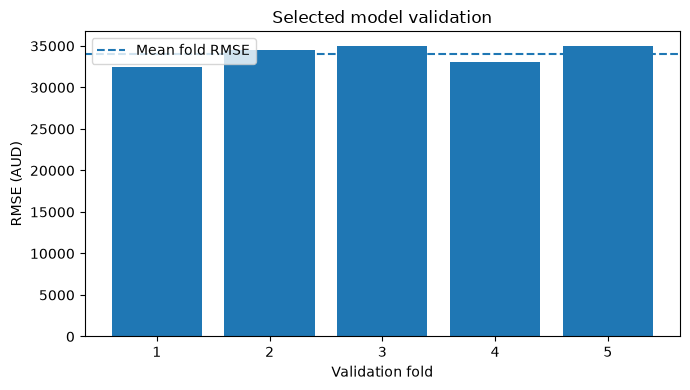

In [9]:
diagnostics = pd.DataFrame({
    "actual": y,
    "prediction": final_oof,
    "requested_amount_aud": train["requested_amount_aud"],
    "sanction_rate": sanction_rate,
    "credit_missing": train["credit_rating"].isna(),
    "approved": y > 0,
})
diagnostics["request_band"] = pd.qcut(diagnostics["requested_amount_aud"], 5)
diagnostics["error"] = diagnostics["actual"] - diagnostics["prediction"]

def error_summary(group):
    return pd.Series({
        "rows": len(group),
        "rmse_aud": rmse(group["actual"], group["prediction"]),
        "mae_aud": mean_absolute_error(group["actual"], group["prediction"]),
        "mean_error_aud": group["error"].mean(),
    })

for group_column in ["approved", "credit_missing", "request_band", "sanction_rate"]:
    print(group_column)
    display(diagnostics.groupby(group_column, observed=True).apply(error_summary, include_groups=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(validation_detail["fold"].astype(str), validation_detail["rmse_aud"])
ax.axhline(validation_summary["mean_fold_rmse_aud"], linestyle="--", label="Mean fold RMSE")
ax.set(xlabel="Validation fold", ylabel="RMSE (AUD)", title="Selected model validation")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Train on all labelled data and create attempt 5

The tables above describe this candidate's own validation errors. We compare errors for approved and rejected applications, missing credit ratings, and request sizes. These are out-of-fold development results, not an independent test.

We now fit the candidate on all labelled rows and save a separate CSV under submissions/. The attempt 4 files are not replaced. The public Kaggle result remains unknown until upload.

In [10]:
final_model = fit_final_model(X_selected, y)
final_prediction = predict_final_model(final_model, X_kaggle_selected).round(2)
submission = sample_submission[["application_id"]].copy()
submission[TARGET] = final_prediction

assert submission.shape == (10000, 2)
assert submission.columns.tolist() == sample_submission.columns.tolist()
assert submission["application_id"].equals(test["application_id"])
assert submission["application_id"].is_unique
assert np.isfinite(submission[TARGET]).all()
assert submission[TARGET].between(0, test["requested_amount_aud"]).all()

submission_path = DATA_DIR / "submissions" / 'submission_catboost_seedavg_attempt5.csv'
submission_path.parent.mkdir(exist_ok=True)
submission.to_csv(submission_path, index=False)
print(f"Saved {submission_path.name}: {len(submission):,} checked predictions.")
display(submission.head())


Saved submission_catboost_seedavg_attempt5.csv: 10,000 checked predictions.


,application_id,sanctioned_amount_aud
0,LN-029039,"68,528.230"
1,LN-006880,"29,906.780"
2,LN-000529,"104,838.360"
3,LN-002049,"173,240.880"
4,LN-000921,621.670


## 10. Reproducibility information

In [11]:
versions = pd.Series({
    "Python": sys.version.split()[0],
    "Platform": platform.platform(),
    "NumPy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "CatBoost": catboost.__version__,
    "random_seed": RANDOM_STATE,
    "validation_folds": N_SPLITS,
    "model_seeds": str(CANDIDATE_CONFIG["seeds"]),
    "final_output": 'submission_catboost_seedavg_attempt5.csv',
})

display(versions)


Python                                               3.11.15
Platform                        macOS-26.6.2-arm64-arm-64bit
NumPy                                                  2.4.6
pandas                                                 3.0.5
scikit-learn                                           1.9.0
CatBoost                                              1.2.10
random_seed                                               42
validation_folds                                           5
model_seeds                                   [42, 73, 2026]
final_output        submission_catboost_seedavg_attempt5.csv
dtype: object